# GarNet Lite: Continuous vs. Quantized

In this Jupyter notebook, we train continuous and quantized versions of GarNet lite and compare their accuracies.

## Setup

In [1]:
%matplotlib inline

## Load Dataset

Fetch from Zenodo

In [2]:
from utils.data import fetch_garnet_dataset

fetch_garnet_dataset(n_files=1)

Split into train and test sets

In [3]:
from utils.data import split_data_and_save

reload_dataset = False
suffix = 'baseline_1'

if reload_dataset is True:
    split_data_and_save(n_files=1, suffix=suffix)

In [4]:
from utils.data import load_data

X_train, y_train, X_test, y_test = load_data(suffix='baseline_1')

# We do not need the cluster sizes here
X_train = X_train[0]
X_test = X_test[0]

## Train the models

Initialize

In [5]:
from hls4ml_garnet_lite.keras_model.garnet_lite import GarNetFactory, QGarNetFactory
from utils.training import garnet_train_config as train_config

keras_model_cont = GarNetFactory().create_keras_model()
keras_model_cont.compile(
    optimizer=train_config.optimizer, loss=train_config.loss_params, loss_weights=train_config.loss_weight_params
)

keras_garnet_precision = (8, 0)
keras_model_quant = QGarNetFactory(8, 4, 8, precision=keras_garnet_precision).create_keras_model()
keras_model_quant.compile(
    optimizer=train_config.optimizer, loss=train_config.loss_params, loss_weights=train_config.loss_weight_params
)

2025-12-01 11:16:04.861966: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2025-12-01 11:16:05.088436: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-12-01 11:16:11.357253: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-12-01 11:16:24.688941: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To tur

Set path where we want to save the models

In [6]:
from utils.files import model_path

cont_model_path = str(model_path / "cont_model.keras")
quant_model_path = str(model_path / "quant_model.keras")

Train the continuous model

In [7]:
retrain = False

if retrain is True:
    keras_model_cont.fit(
        x=X_train,
        y={"regression": y_train[0], "classification": y_train[1]},
        epochs=train_config.epochs,
        callbacks=train_config.callbacks,
        validation_split=train_config.validation_split,
        batch_size=train_config.batch_size,
        shuffle=True,
        verbose=1,
    )
    keras_model_cont.save(cont_model_path)

Train the quantized model

In [8]:
retrain = False

if retrain is True:
    keras_model_quant.fit(
        x=X_train,
        y={"regression": y_train[0], "classification": y_train[1]},
        epochs=train_config.epochs,
        callbacks=train_config.callbacks,
        validation_split=train_config.validation_split,
        batch_size=train_config.batch_size,
        shuffle=True,
        verbose=1,
    )
    keras_model_quant.save(quant_model_path)

Load the models

In [9]:
from keras.saving import load_model

keras_model_cont = load_model(cont_model_path)
keras_model_quant = load_model(quant_model_path)

## Comparison of continuous and quantized models 

Predict

In [10]:
from utils.evaluation import garnet_predict

y_energy_pred_cont, y_pid_pred_cont = garnet_predict(keras_model_cont, X_test)
y_energy_pred_quant, y_pid_pred_quant = garnet_predict(keras_model_quant, X_test)

y_energy_pred_cont *= 100
y_energy_pred_quant *= 100

79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
79/79 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step


### Compare predictions

#### Classification

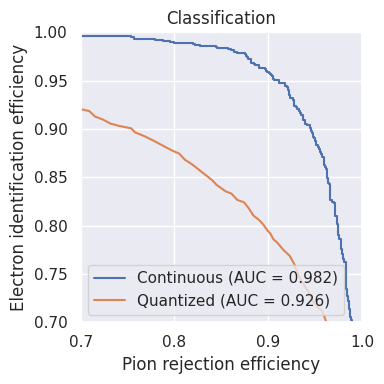

In [11]:
import seaborn as sns
from matplotlib import pyplot as plt
from sklearn.metrics import auc, roc_curve

sns.set_theme()
sns.set_style('darkgrid')

fpr_cont, tpr_cont, thresh_cont = roc_curve(y_test[1], y_pid_pred_cont, pos_label=1)
fpr_quant, tpr_quant, thresh_quant = roc_curve(y_test[1], y_pid_pred_quant, pos_label=1)

auc_cont = auc(1 - fpr_cont, tpr_cont)
auc_quant = auc(1 - fpr_quant, tpr_quant)

fig = plt.figure(figsize=(4, 4))
plt.plot(1 - fpr_cont, tpr_cont, label=f"Continuous (AUC = {auc_cont:.3f})")
plt.plot(1 - fpr_quant, tpr_quant, label=f"Quantized (AUC = {auc_quant:.3f})")
plt.ylim((0.7, 1))
plt.xlim((0.7, 1))
plt.xlabel('Pion rejection efficiency')
plt.ylabel('Electron identification efficiency')
plt.title("Classification")
plt.legend()
plt.tight_layout()
plt.show()

#### Regression

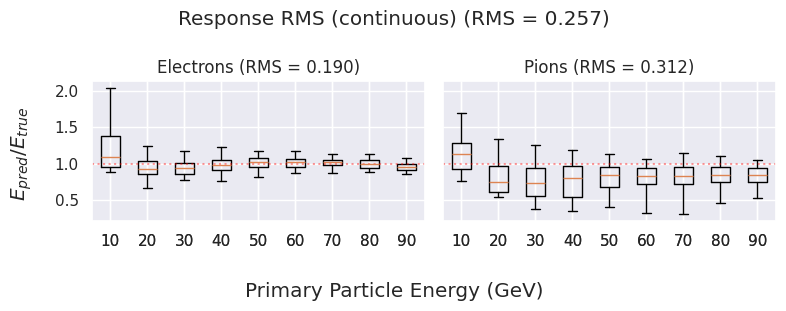

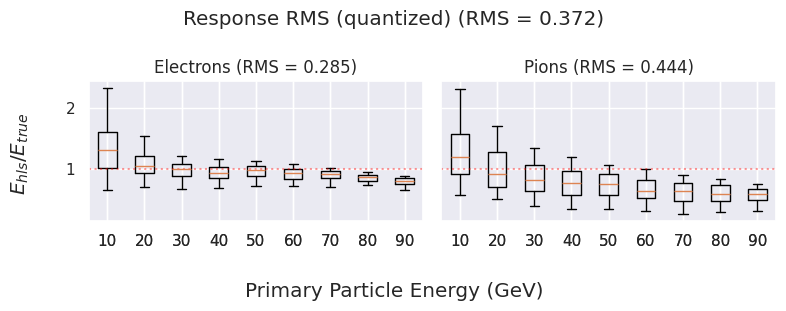

In [12]:
import numpy as np

from utils.evaluation import response_boxplot

response_boxplot(
    y_test[1],
    y_test[0],
    np.reshape(y_energy_pred_cont, (y_energy_pred_cont.shape[0],)),
    "Response RMS (continuous)",
    "$E_{pred}/E_{true}$",
)
response_boxplot(
    y_test[1],
    y_test[0],
    np.reshape(y_energy_pred_quant, (y_energy_pred_quant.shape[0],)),
    "Response RMS (quantized)",
    "$E_{hls}/E_{true}$",
)